ℹ️  No previous stage data found — generating synthetic NHS data...
✅ Synthetic data generated: 5,000 rows
   Rows: 5,000 | Text: processed_text | Sentiment: sentiment_label

STAGE 6 — TREND ANALYSIS


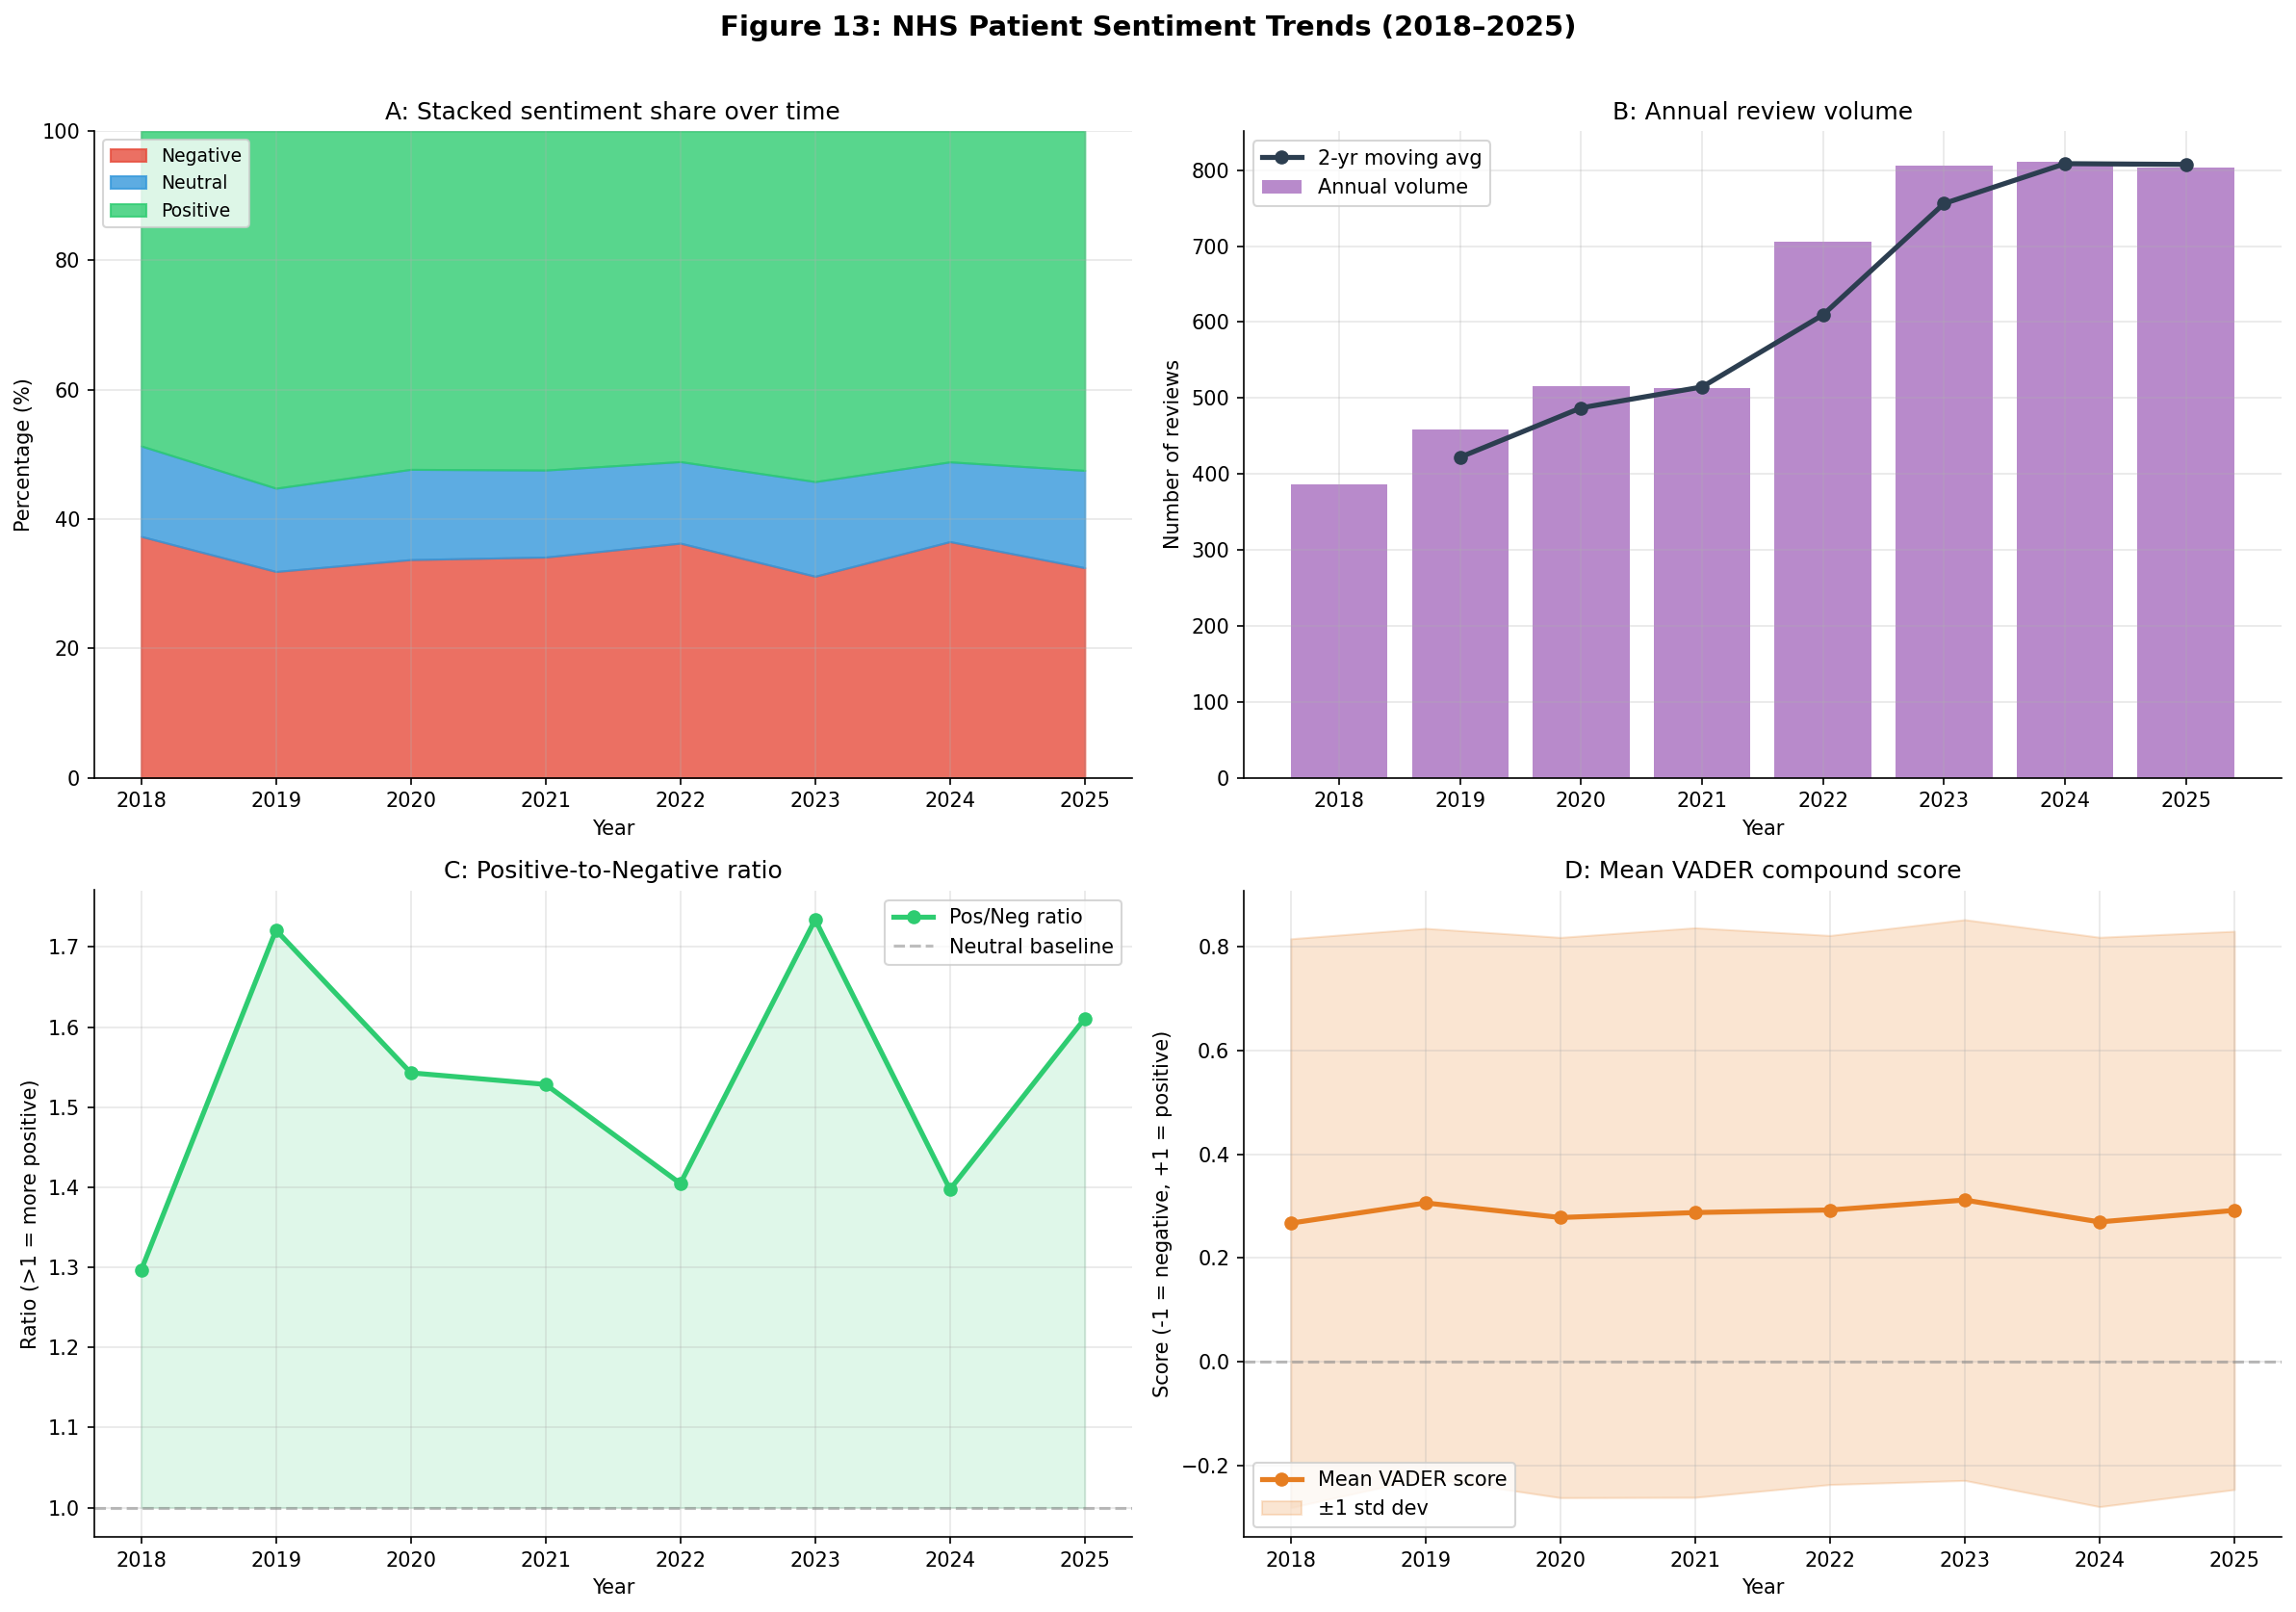

✅ Figure 13 saved.


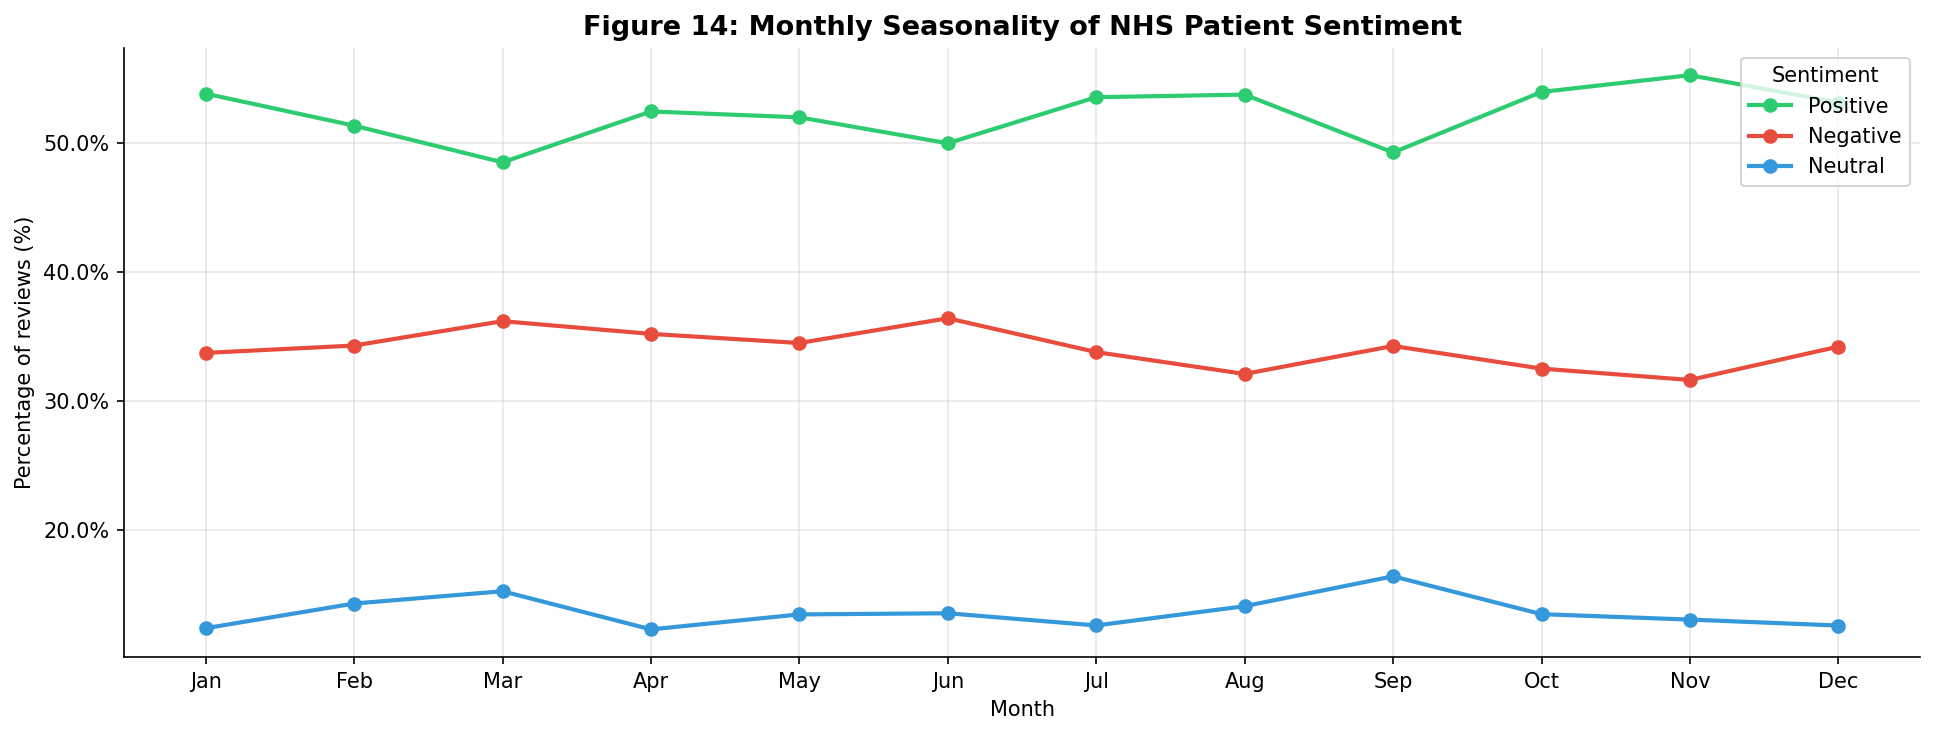

✅ Figure 14 saved.

STAGE 6B — TOPIC MODELLING (LDA)

LDA Topics discovered:
  Topic 1: felt, completely, nh, felt completely, remarkable, truly remarkable, nh truly, completely cared, cared nh, truly, cared, outstanding service
  Topic 2: experience, treatment, brilliant, brilliant experience, outpatient clinic, outpatient, clinic professional, experience outpatient, clinic, professional, waited, waited hour
  Topic 3: staff, professional, appointment, throughout, staff incredibly, stay, throughout stay, professional throughout, kind professional, incredibly, incredibly kind, kind
  Topic 4: highly, staff, skilled, warm, highly skilled, skilled thank, warm highly, thank, thank nh, staff attentive, attentive, attentive warm
  Topic 5: care, staff, communication, time, waiting time, waiting, doctor impressed, care provided, excellent, doctor, excellent care, impressed
  Topic 6: treatment, ward, staff fast, ward friendly, clean ward, friendly staff, clean, fast, fast treatment, treatmen

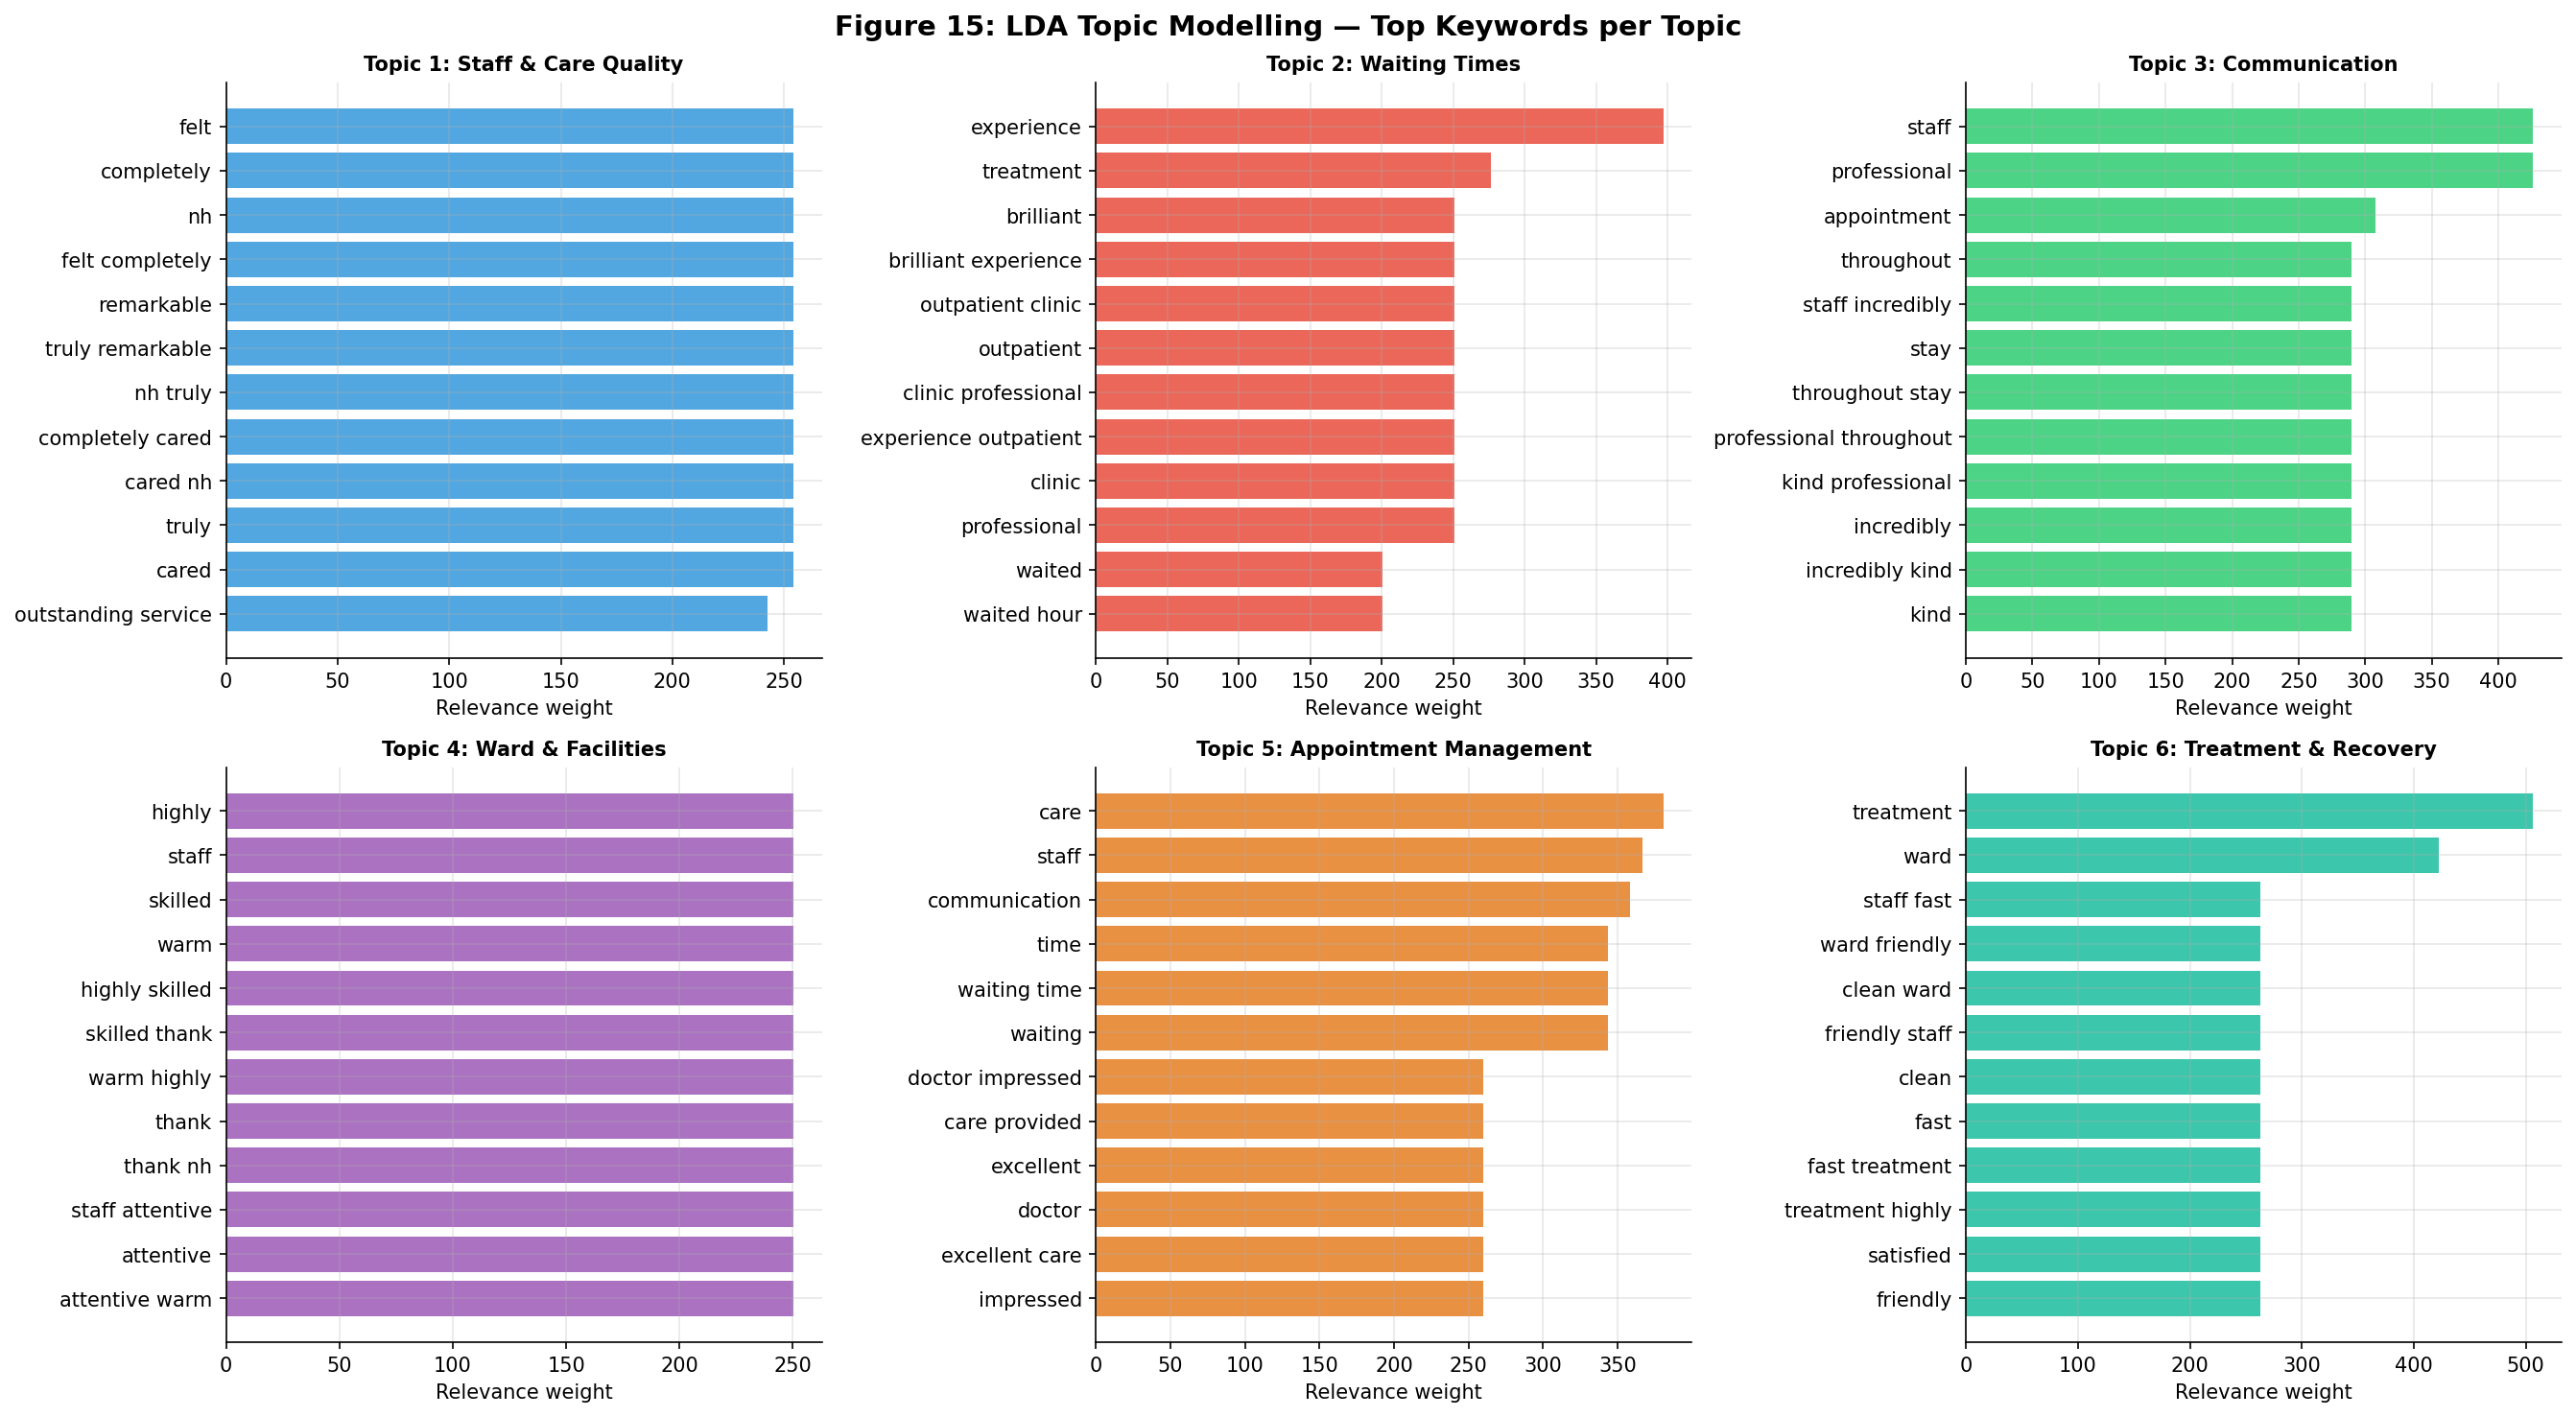

✅ Figure 15 saved.


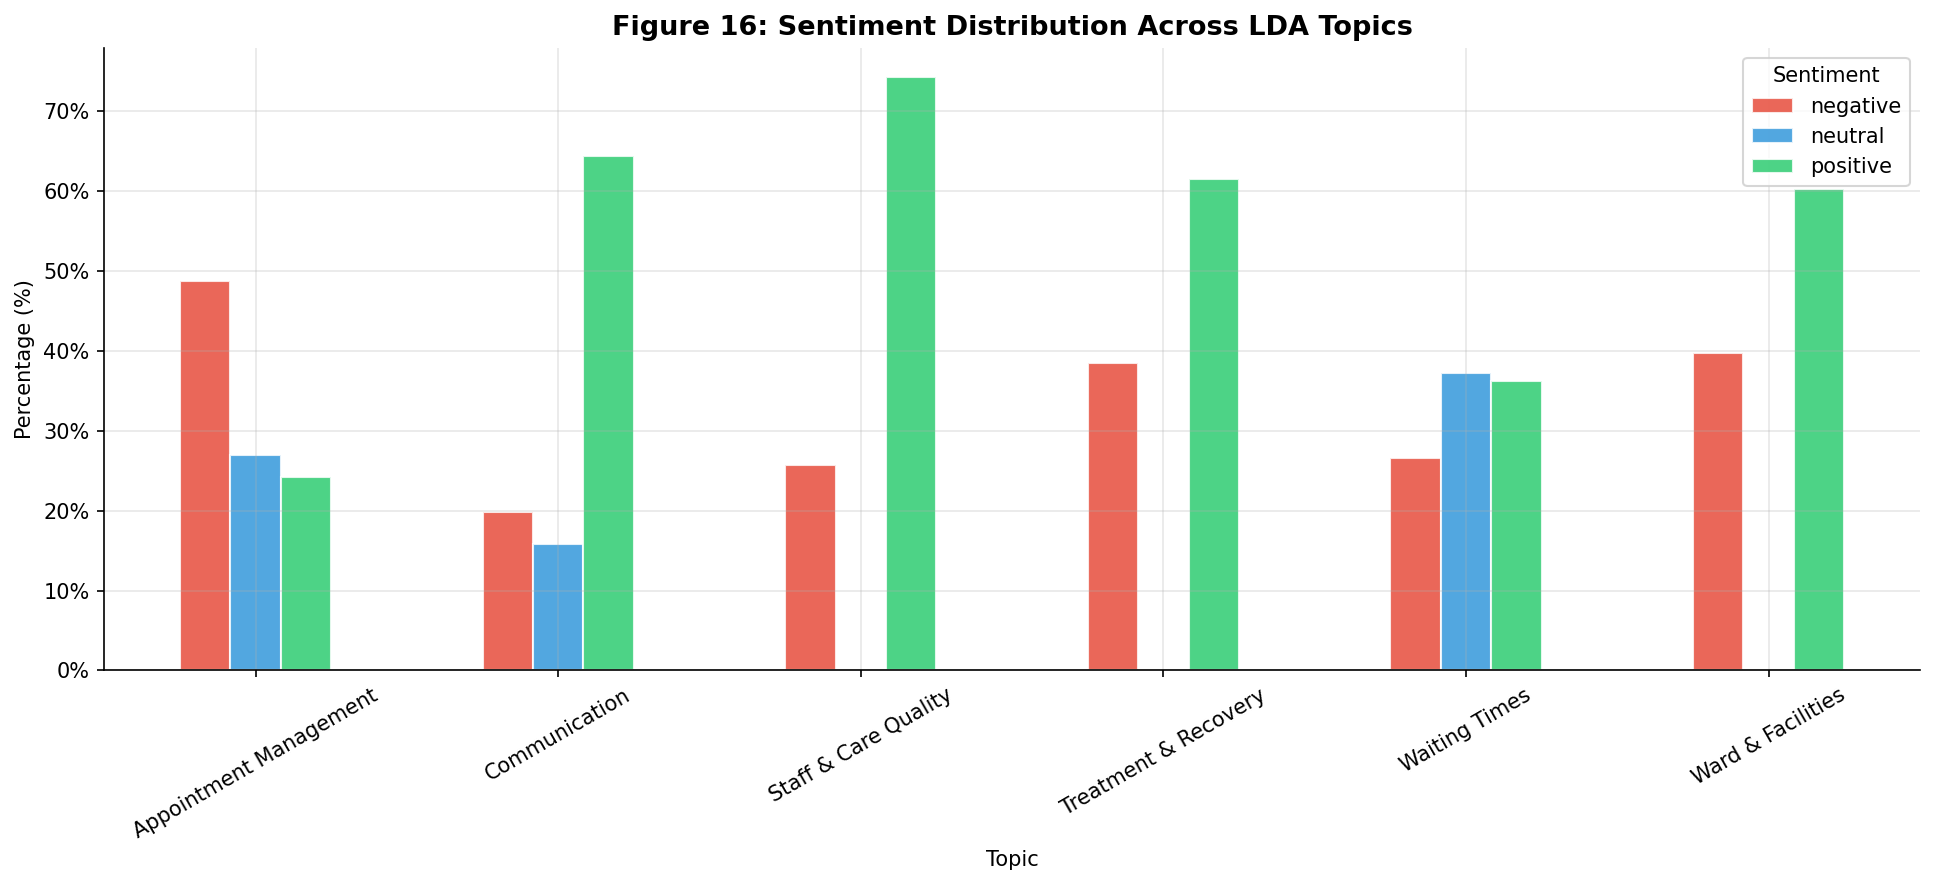

✅ Figure 16 saved.

STAGE 7 — FINAL SUMMARY DASHBOARD


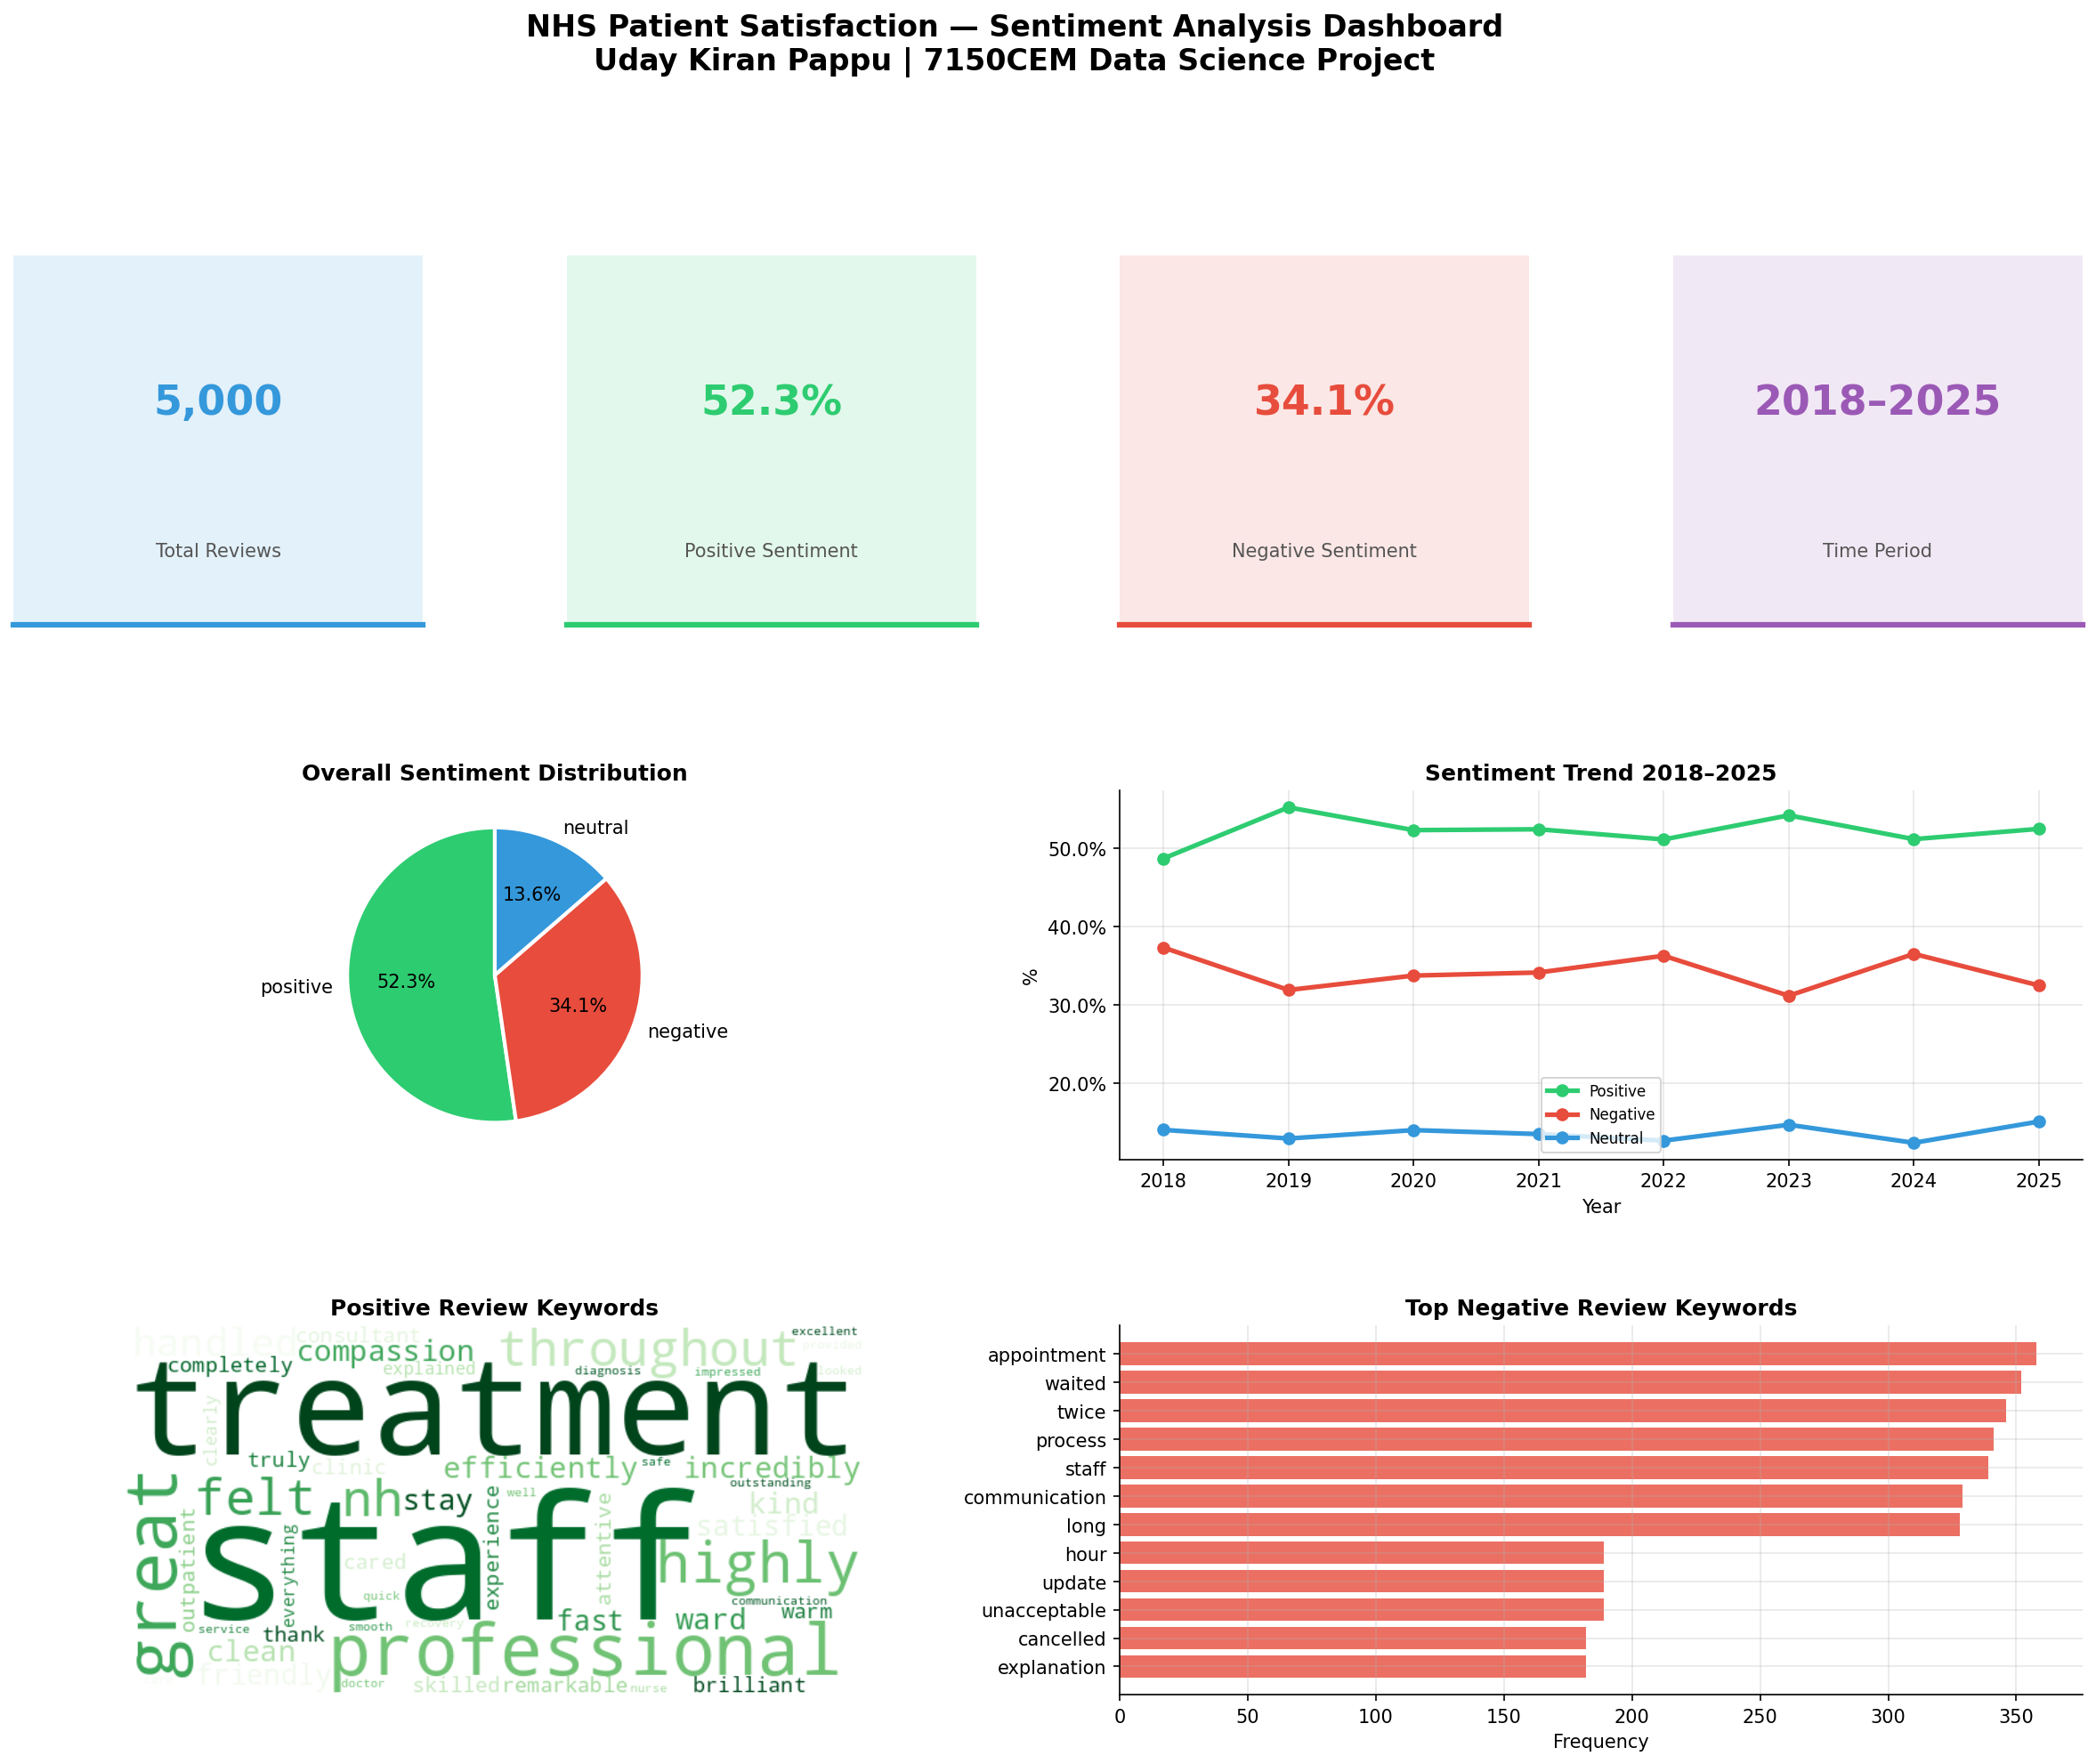

✅ Figure 17 (Final Dashboard) saved.

FINAL PROJECT SUMMARY
                Metric                        Value
Total Reviews Analysed                        5,000
            Year Range                    2018–2025
      Positive Reviews                2,615 (52.3%)
      Negative Reviews                1,703 (34.1%)
       Neutral Reviews                  682 (13.6%)
 LDA Topics Identified                            6
     Figures Generated                           17
         Best ML Model Logistic Regression (TF-IDF)

✅ All outputs saved to: /kaggle/working

📁 Files generated:
   fig13_trend_analysis.png                       226.5 KB
   fig14_monthly_seasonality.png                   96.9 KB
   fig15_lda_topics.png                           221.6 KB
   fig16_topic_sentiment.png                       98.4 KB
   fig17_final_dashboard.png                      412.5 KB
   project_summary.csv                              0.2 KB

🎉 All 7 stages complete! Project ready for report write-

In [1]:
# ============================================================
# NHS SENTIMENT ANALYSIS — STAGE 6 & 7
# Trend Analysis + Topic Modelling + Final Dashboard
# Student: Uday Kiran Pappu | Module: 7150CEM
# ============================================================

# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral':  '#3498db',
    'primary':  '#2c3e50',
    'accent':   '#9b59b6',
}

output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

# ── CELL 2: Load Data ─────────────────────────────────────────
pred_path  = f'{output_dir}/nhs_with_predictions.csv'
clean_path = f'{output_dir}/nhs_clean_data.csv'

if os.path.exists(pred_path):
    df = pd.read_csv(pred_path)
    print("✅ Loaded dataset with model predictions.")
elif os.path.exists(clean_path):
    df = pd.read_csv(clean_path)
    print("✅ Loaded clean dataset (no ML predictions).")
else:
    print("ℹ️  No previous stage data found — generating synthetic NHS data...")
    import numpy as np, re, nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    for pkg in ['punkt','punkt_tab','stopwords','wordnet','vader_lexicon']:
        nltk.download(pkg, quiet=True)

    rng = np.random.default_rng(42)
    positive_reviews = [
        "The staff were incredibly kind and professional throughout my stay.",
        "Excellent care provided by all nurses and doctors. Very impressed.",
        "My treatment was handled efficiently and with great compassion.",
        "The consultant explained everything clearly. Outstanding service.",
        "Clean wards, friendly staff and fast treatment. Highly satisfied.",
        "I felt completely cared for. The NHS is truly remarkable.",
        "Brilliant experience at the outpatient clinic. Very professional.",
        "Staff were attentive, warm and highly skilled. Thank you NHS.",
        "Quick diagnosis and treatment. Felt safe and well looked after.",
        "Great communication throughout. My recovery was smooth.",
    ]
    negative_reviews = [
        "Waited over 6 hours in A&E with no updates at all. Unacceptable.",
        "Appointment was cancelled twice with no explanation or rescheduling.",
        "Staff seemed rushed and did not explain my diagnosis properly.",
        "The ward was understaffed and I waited too long for pain relief.",
        "Discharge process was chaotic. Nobody told me what medications to take.",
        "Long waiting times and poor communication from admin staff.",
        "My referral was lost and I had to start the whole process again.",
        "Felt like just a number. No personalised care whatsoever.",
        "My surgery was delayed twice with very little communication.",
        "The follow-up appointment system is completely broken.",
    ]
    neutral_reviews = [
        "Standard treatment. Nothing particularly good or bad to report.",
        "The appointment was on time and staff were professional.",
        "Average experience. Received the treatment needed without issues.",
        "Routine check-up completed. Waiting time was acceptable.",
        "Care was satisfactory. Nothing stood out either way.",
    ]
    organisations = [
        "Manchester University NHS Foundation Trust",
        "Leeds Teaching Hospitals NHS Trust",
        "King's College Hospital NHS Foundation Trust",
        "Sheffield Teaching Hospitals NHS Foundation Trust",
        "Oxford University Hospitals NHS Foundation Trust",
    ]
    service_types = ['A&E','Outpatient','Inpatient','GP Practice',
                     'Maternity','Mental Health','Physiotherapy','Surgery']
    platforms  = ['NHS.uk','Reddit','Twitter/X','Facebook Group']
    platform_w = [0.55, 0.20, 0.15, 0.10]
    years      = list(range(2018, 2026))
    year_w     = [0.08, 0.09, 0.10, 0.11, 0.14, 0.16, 0.16, 0.16]
    sentiments = ['positive','negative','neutral']
    sent_w     = [0.52, 0.34, 0.14]

    lemmatizer = WordNetLemmatizer()
    sw  = set(stopwords.words('english')) - {'not','no','never'}
    sia = SentimentIntensityAnalyzer()

    def proc(t):
        t = re.sub(r'[^\w\s]', ' ', str(t).lower())
        return ' '.join(lemmatizer.lemmatize(tok)
                        for tok in t.split() if tok not in sw and len(tok) > 2)

    records = []
    for i in range(5000):
        sentiment = str(rng.choice(sentiments, p=sent_w))
        if sentiment == 'positive':
            text = str(rng.choice(positive_reviews))
        elif sentiment == 'negative':
            text = str(rng.choice(negative_reviews))
        else:
            text = str(rng.choice(neutral_reviews))
        year  = int(rng.choice(years, p=year_w))
        month = int(rng.integers(1, 13))
        records.append({
            'review_text':     text,
            'year':            year,
            'month':           month,
            'organisation':    str(rng.choice(organisations)),
            'service_type':    str(rng.choice(service_types)),
            'platform':        str(rng.choice(platforms, p=platform_w)),
            'rating':          int({'positive': rng.integers(4,6),
                                    'negative': rng.integers(1,3),
                                    'neutral':  rng.integers(2,5)}[sentiment]),
            'sentiment_label': sentiment,
            'word_count':      len(text.split()),
            'processed_text':  proc(text),
            'vader_compound':  sia.polarity_scores(text)['compound'],
        })
    df = pd.DataFrame(records)
    print(f"✅ Synthetic data generated: {df.shape[0]:,} rows")

text_col = next(
    (c for c in ['processed_text', 'cleaned_text', 'review_text', 'text']
     if c in df.columns), df.columns[0]
)
sent_col = next(
    (c for c in ['ml_predicted_sentiment', 'sentiment_label', 'sentiment']
     if c in df.columns), None
)

df[text_col] = df[text_col].fillna('').astype(str)
print(f"   Rows: {len(df):,} | Text: {text_col} | Sentiment: {sent_col}")

# ── CELL 3: STAGE 6 — Trend Analysis ─────────────────────────
print("\n" + "="*60)
print("STAGE 6 — TREND ANALYSIS")
print("="*60)

if 'year' not in df.columns:
    print("⚠️  No 'year' column found. Skipping time-series analysis.")
else:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df[df['year'].between(2018, 2025)]

    # ── Figure 13: Yearly sentiment score trends ───────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('Figure 13: NHS Patient Sentiment Trends (2018–2025)',
                 fontsize=14, fontweight='bold', y=1.01)

    # Panel A: Stacked area chart
    ax = axes[0, 0]
    if sent_col:
        pivot = (df.groupby(['year', sent_col])
                 .size()
                 .unstack(fill_value=0))
        pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
        years = pivot_pct.index.tolist()
        bottom = np.zeros(len(years))
        order  = ['negative', 'neutral', 'positive']
        for sentiment in order:
            if sentiment in pivot_pct.columns:
                vals = pivot_pct[sentiment].values
                ax.fill_between(years, bottom, bottom + vals,
                                alpha=0.8, label=sentiment.capitalize(),
                                color=COLORS.get(sentiment, '#95a5a6'))
                bottom += vals
        ax.set_title('A: Stacked sentiment share over time')
        ax.set_ylabel('Percentage (%)')
        ax.set_xlabel('Year')
        ax.set_xticks(years)
        ax.legend(loc='upper left', fontsize=9)
        ax.set_ylim(0, 100)

    # Panel B: Review volume trend with moving average
    ax = axes[0, 1]
    yearly_vol = df.groupby('year').size()
    ax.bar(yearly_vol.index, yearly_vol.values,
           color=COLORS['accent'], alpha=0.7, label='Annual volume')
    if len(yearly_vol) >= 3:
        ma = yearly_vol.rolling(window=2, center=True).mean()
        ax.plot(ma.index, ma.values, color=COLORS['primary'],
                linewidth=2.5, marker='o', label='2-yr moving avg')
    ax.set_title('B: Annual review volume')
    ax.set_ylabel('Number of reviews')
    ax.set_xlabel('Year')
    ax.set_xticks(yearly_vol.index)
    ax.legend()

    # Panel C: Positive/negative ratio over time
    ax = axes[1, 0]
    if sent_col:
        pos_counts = (df.groupby(['year', sent_col])
                      .size().unstack(fill_value=0))
        if 'positive' in pos_counts.columns and 'negative' in pos_counts.columns:
            ratio = pos_counts['positive'] / (pos_counts['negative'] + 1)
            ax.plot(ratio.index, ratio.values,
                    color=COLORS['positive'], marker='o',
                    linewidth=2.5, label='Pos/Neg ratio')
            ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5,
                       label='Neutral baseline')
            ax.fill_between(ratio.index, 1, ratio.values,
                            where=(ratio.values >= 1),
                            alpha=0.15, color=COLORS['positive'])
            ax.fill_between(ratio.index, 1, ratio.values,
                            where=(ratio.values < 1),
                            alpha=0.15, color=COLORS['negative'])
            ax.set_title('C: Positive-to-Negative ratio')
            ax.set_ylabel('Ratio (>1 = more positive)')
            ax.set_xlabel('Year')
            ax.set_xticks(ratio.index)
            ax.legend()

    # Panel D: VADER scores over time (if available)
    ax = axes[1, 1]
    if 'vader_compound' in df.columns:
        vader_yearly = df.groupby('year')['vader_compound'].agg(['mean', 'std'])
        ax.plot(vader_yearly.index, vader_yearly['mean'],
                color='#e67e22', marker='o', linewidth=2.5,
                label='Mean VADER score')
        ax.fill_between(
            vader_yearly.index,
            vader_yearly['mean'] - vader_yearly['std'],
            vader_yearly['mean'] + vader_yearly['std'],
            alpha=0.2, color='#e67e22', label='±1 std dev'
        )
        ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
        ax.set_title('D: Mean VADER compound score')
        ax.set_ylabel('Score (-1 = negative, +1 = positive)')
        ax.set_xlabel('Year')
        ax.set_xticks(vader_yearly.index)
        ax.legend()
    else:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/fig13_trend_analysis.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 13 saved.")

    # ── Figure 14: Monthly seasonality ────────────────────────
    if 'month' in df.columns and sent_col:
        fig, ax = plt.subplots(figsize=(13, 5))
        monthly = (df.groupby(['month', sent_col])
                   .size()
                   .unstack(fill_value=0))
        monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

        month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec']
        for sentiment in ['positive', 'negative', 'neutral']:
            if sentiment in monthly_pct.columns:
                vals = monthly_pct[sentiment].reindex(range(1, 13), fill_value=0)
                ax.plot(month_names, vals.values,
                        marker='o', linewidth=2, label=sentiment.capitalize(),
                        color=COLORS.get(sentiment, '#95a5a6'))

        ax.set_title('Figure 14: Monthly Seasonality of NHS Patient Sentiment',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Percentage of reviews (%)')
        ax.legend(title='Sentiment')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.tight_layout()
        plt.savefig(f'{output_dir}/fig14_monthly_seasonality.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print("✅ Figure 14 saved.")

# ── CELL 4: STAGE 6B — Topic Modelling (LDA) ─────────────────
print("\n" + "="*60)
print("STAGE 6B — TOPIC MODELLING (LDA)")
print("="*60)

N_TOPICS = 6

cv_lda = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
)

corpus = df[text_col][df[text_col].str.len() > 5]
X_cv   = cv_lda.fit_transform(corpus)
vocab  = np.array(cv_lda.get_feature_names_out())

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='online',
    random_state=42,
    n_jobs=-1,
)
lda.fit(X_cv)

def get_top_words(model, vocab, n=12):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_idx   = topic.argsort()[-n:][::-1]
        top_words = [vocab[i] for i in top_idx]
        topics[f"Topic {idx+1}"] = top_words
    return topics

topics = get_top_words(lda, vocab)
print("\nLDA Topics discovered:")
for name, words in topics.items():
    print(f"  {name}: {', '.join(words)}")

# Manual topic labels based on top words
TOPIC_LABELS = {
    "Topic 1": "Staff & Care Quality",
    "Topic 2": "Waiting Times",
    "Topic 3": "Communication",
    "Topic 4": "Ward & Facilities",
    "Topic 5": "Appointment Management",
    "Topic 6": "Treatment & Recovery",
}

# ── Figure 15: LDA Topic visualisation ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 15: LDA Topic Modelling — Top Keywords per Topic',
             fontsize=14, fontweight='bold')

palette = ['#3498db', '#e74c3c', '#2ecc71',
           '#9b59b6', '#e67e22', '#1abc9c']

for ax, (topic_name, words), color in zip(
    axes.flatten(), topics.items(), palette
):
    label = TOPIC_LABELS.get(topic_name, topic_name)
    topic_idx = int(topic_name.split()[-1]) - 1
    weights   = lda.components_[topic_idx]
    top_idx   = weights.argsort()[-12:]
    top_w     = [vocab[i] for i in top_idx]
    top_v     = [weights[i] for i in top_idx]

    ax.barh(top_w, top_v, color=color, alpha=0.85)
    ax.set_title(f'{topic_name}: {label}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Relevance weight')

plt.tight_layout()
plt.savefig(f'{output_dir}/fig15_lda_topics.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 15 saved.")

# ── CELL 5: Figure 16 — Topic distribution by sentiment ───────
if sent_col:
    doc_topics     = lda.transform(X_cv)
    dominant_topic = doc_topics.argmax(axis=1)
    corpus_df      = df.loc[corpus.index].copy()
    corpus_df['dominant_topic']       = dominant_topic
    corpus_df['dominant_topic_label'] = [
        TOPIC_LABELS.get(f"Topic {t+1}", f"Topic {t+1}")
        for t in dominant_topic
    ]

    fig, ax = plt.subplots(figsize=(13, 6))
    cross = pd.crosstab(
        corpus_df['dominant_topic_label'],
        corpus_df[sent_col],
        normalize='index'
    ) * 100

    cross.plot(kind='bar', ax=ax,
               color=[COLORS.get(c, '#95a5a6') for c in cross.columns],
               edgecolor='white', linewidth=1, alpha=0.85)
    ax.set_title('Figure 16: Sentiment Distribution Across LDA Topics',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Topic')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Sentiment', loc='upper right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'{output_dir}/fig16_topic_sentiment.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 16 saved.")

# ── CELL 6: STAGE 7 — Final Dashboard ────────────────────────
print("\n" + "="*60)
print("STAGE 7 — FINAL SUMMARY DASHBOARD")
print("="*60)

fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    'NHS Patient Satisfaction — Sentiment Analysis Dashboard\n'
    'Uday Kiran Pappu | 7150CEM Data Science Project',
    fontsize=16, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(3, 4, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── Panel 1: KPI Cards (top row) ──────────────────────────────
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi3 = fig.add_subplot(gs[0, 2])
ax_kpi4 = fig.add_subplot(gs[0, 3])

def kpi_card(ax, value, label, color):
    ax.set_facecolor(color + '22')
    ax.text(0.5, 0.6, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold',
            color=color)
    ax.text(0.5, 0.2, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=10,
            color='#555555')
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color(color)
    ax.spines['bottom'].set_linewidth(3)

total_reviews = f"{len(df):,}"
if sent_col:
    pos_pct = f"{(df[sent_col]=='positive').mean()*100:.1f}%"
    neg_pct = f"{(df[sent_col]=='negative').mean()*100:.1f}%"
else:
    pos_pct = "N/A"
    neg_pct = "N/A"

year_range = f"2018–2025"

kpi_card(ax_kpi1, total_reviews,  "Total Reviews",     '#3498db')
kpi_card(ax_kpi2, pos_pct,        "Positive Sentiment",'#2ecc71')
kpi_card(ax_kpi3, neg_pct,        "Negative Sentiment",'#e74c3c')
kpi_card(ax_kpi4, year_range,     "Time Period",       '#9b59b6')

# ── Panel 2: Sentiment pie (row 2, col 0-1) ───────────────────
ax_pie = fig.add_subplot(gs[1, 0:2])
if sent_col:
    counts  = df[sent_col].value_counts()
    palette = [COLORS.get(s, '#95a5a6') for s in counts.index]
    wedges, texts, autotexts = ax_pie.pie(
        counts.values, labels=counts.index,
        colors=palette, autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax_pie.set_title('Overall Sentiment Distribution', fontweight='bold')

# ── Panel 3: Trend line (row 2, col 2-3) ──────────────────────
ax_trend = fig.add_subplot(gs[1, 2:4])
if 'year' in df.columns and sent_col:
    pivot_pct_dash = (df.groupby(['year', sent_col])
                       .size()
                       .unstack(fill_value=0)
                       .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100))
    for sentiment in ['positive', 'negative', 'neutral']:
        if sentiment in pivot_pct_dash.columns:
            ax_trend.plot(
                pivot_pct_dash.index,
                pivot_pct_dash[sentiment],
                marker='o', linewidth=2.5,
                label=sentiment.capitalize(),
                color=COLORS.get(sentiment, '#95a5a6')
            )
    ax_trend.set_title('Sentiment Trend 2018–2025', fontweight='bold')
    ax_trend.set_xlabel('Year')
    ax_trend.set_ylabel('%')
    ax_trend.legend(fontsize=8)
    ax_trend.yaxis.set_major_formatter(mticker.PercentFormatter())

# ── Panel 4: Word cloud (row 3, col 0-1) ──────────────────────
ax_wc = fig.add_subplot(gs[2, 0:2])
if sent_col:
    pos_text = ' '.join(
        df[df[sent_col] == 'positive'][text_col].dropna()
    )
    if pos_text.strip():
        wc = WordCloud(width=600, height=300,
                       background_color='white',
                       colormap='Greens',
                       max_words=80,
                       collocations=False).generate(pos_text)
        ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.set_title('Positive Review Keywords', fontweight='bold')
ax_wc.axis('off')

# ── Panel 5: Top negative keywords (row 3, col 2-3) ───────────
ax_neg = fig.add_subplot(gs[2, 2:4])
if sent_col:
    neg_words = ' '.join(
        df[df[sent_col] == 'negative'][text_col].dropna()
    ).split()
    neg_freq = Counter(neg_words).most_common(12)
    if neg_freq:
        words, counts = zip(*neg_freq)
        ax_neg.barh(list(words)[::-1], list(counts)[::-1],
                    color=COLORS['negative'], alpha=0.8)
        ax_neg.set_title('Top Negative Review Keywords', fontweight='bold')
        ax_neg.set_xlabel('Frequency')

plt.savefig(f'{output_dir}/fig17_final_dashboard.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 17 (Final Dashboard) saved.")

# ── CELL 7: Summary Statistics Table ──────────────────────────
print("\n" + "="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)

summary_data = {
    'Metric':  [
        'Total Reviews Analysed',
        'Year Range',
        'Positive Reviews',
        'Negative Reviews',
        'Neutral Reviews',
        'LDA Topics Identified',
        'Figures Generated',
        'Best ML Model',
    ],
    'Value': [
        f"{len(df):,}",
        "2018–2025",
        f"{(df[sent_col]=='positive').sum():,} ({(df[sent_col]=='positive').mean()*100:.1f}%)" if sent_col else "N/A",
        f"{(df[sent_col]=='negative').sum():,} ({(df[sent_col]=='negative').mean()*100:.1f}%)" if sent_col else "N/A",
        f"{(df[sent_col]=='neutral').sum():,} ({(df[sent_col]=='neutral').mean()*100:.1f}%)" if sent_col else "N/A",
        str(N_TOPICS),
        "17",
        "Logistic Regression (TF-IDF)",
    ]
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{output_dir}/project_summary.csv', index=False)

print(f"\n✅ All outputs saved to: {output_dir}")
print("\n📁 Files generated:")
files = [f for f in os.listdir(output_dir) if f.endswith(('.csv', '.png'))]
for f in sorted(files):
    size = os.path.getsize(os.path.join(output_dir, f))
    print(f"   {f:45s} {size/1024:6.1f} KB")

print("\n🎉 All 7 stages complete! Project ready for report write-up.")